### 1. Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Import simulation mechanics cleanly from our decoupled python file
from sionna_dg import (
    SimConfig,
    generate_dataset_offline,
    simulate_full_frames_tf,
    classical_receiver,
    build_sionna_blocks
)

2026-03-04 13:54:21.214132: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 13:54:22.738345: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 2. Globals, hyperparameters, devices

In [2]:
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# Configuration explicitly matched to the 152,088 parameter architecture
cfg_ofdm = SimConfig(
    num_examples=10000,
    bits_per_symbol=4,
    k=256,
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    include_pilot_overhead_in_no=True,
    waveform="ofdm",
    ofdm_fft_size=64,
    ofdm_cp_len=16,
    ofdm_num_data_symbols=2,
    ofdm_num_pilot_symbols=1,
)

Using Device: cuda


### 3. Utils and helpers

In [3]:
def set_seed_all(seed: int = 46):
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(cfg_ofdm.seed)

### 4. Data loading

In [4]:
def get_pytorch_ofdm_loaders(base_cfg, batch_size=128):
    print("Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...")
    
    cfg_main = SimConfig(**{**base_cfg.__dict__, "num_examples": 8000, "ebn0_db_min": 4.0, "ebn0_db_max": 8.0})
    cfg_rand = SimConfig(**{**base_cfg.__dict__, "num_examples": 2000, "ebn0_db_min": 0.0, "ebn0_db_max": 12.0})
    
    ds_main = generate_dataset_offline(cfg_main)
    ds_rand = generate_dataset_offline(cfg_rand)
    
    x_rx = np.concatenate([ds_main["rx_iq_data_time"], ds_rand["rx_iq_data_time"]], axis=0) 
    x_pilot = np.concatenate([ds_main["rx_iq_pilot_time"], ds_rand["rx_iq_pilot_time"]], axis=0) 
    target_bits = np.concatenate([ds_main["coded_bits"], ds_rand["coded_bits"]], axis=0) 
    
    tx_grid_main = ds_main["tx_grid"] 
    tx_grid_rand = ds_rand["tx_grid"]
    n_pilot_sym = base_cfg.ofdm_num_pilot_symbols 
    
    x_data_main = tx_grid_main[:, n_pilot_sym:, :, :].reshape(tx_grid_main.shape[0], -1, 2) 
    x_data_rand = tx_grid_rand[:, n_pilot_sym:, :, :].reshape(tx_grid_rand.shape[0], -1, 2) 
    x_data = np.concatenate([x_data_main, x_data_rand], axis=0) 
    
    phi0 = np.concatenate([ds_main["phi0"], ds_rand["phi0"]], axis=0) 
    cfo = np.concatenate([ds_main["cfo_norm"], ds_rand["cfo_norm"]], axis=0) 
    
    x_rx_t = torch.tensor(x_rx).permute(0, 2, 1).float()
    x_pilot_t = torch.tensor(x_pilot).permute(0, 2, 1).float()
    target_bits_t = torch.tensor(target_bits).reshape(-1, base_cfg.seq_length, 4).permute(0, 2, 1).float()
    target_iq_t = torch.tensor(x_data).permute(0, 2, 1).float()
    
    phi0_t = torch.tensor(phi0).float().squeeze(-1)
    cfo_t = torch.tensor(cfo).float().squeeze(-1)
    
    dataset = TensorDataset(x_rx_t, x_pilot_t, phi0_t, cfo_t, target_bits_t, target_iq_t)
    
    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)

### 5. Model definition and architecture

In [ ]:
# 2. Ablated Architecture (1D CNN version)
class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))

class HybridNeuralReceiverOFDM(nn.Module):
    def __init__(self, seq_len=160, n_pilots=80, ofdm_fft_size=64, ofdm_cp_len=16):
        super().__init__()
        self.fft_size = ofdm_fft_size
        self.cp_len = ofdm_cp_len
        
        in_dim = (2 * seq_len) + (2 * n_pilots)
        self.input_norm = nn.BatchNorm1d(in_dim)
        
        self.estimator = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 2) 
        )
        
        # We keep latent_proj so the model has the same input features, 
        # but we can use it for conditioning (FiLM) or simply bypass it.
        self.latent_proj = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 64), nn.Tanh())
        
        self.feat_extract = nn.Conv1d(2, 64, 7, padding=3)
        self.res1 = ResidualBlock1D(64)
        
        # REPLACEMENT: Instead of Attention, we add 2 extra Residual Blocks (1D CNN)
        self.cnn_mid1 = ResidualBlock1D(64)
        self.cnn_mid2 = ResidualBlock1D(64)
        
        self.res2 = ResidualBlock1D(64)
        
        self.iq_head = nn.Conv1d(64, 2, 1) 
        self.demap_mlp = nn.Sequential(
            nn.Conv1d(64, 32, 1), nn.ReLU(),
            nn.Conv1d(32, 16, 1), nn.ReLU(),
            nn.Conv1d(16, 4, 1)
        )

    def forward(self, x, pilots, gt_phi=None, gt_cfo=None, mix_ratio=0.0):
        x_flat = x.reshape(x.size(0), -1)
        p_flat = pilots.reshape(pilots.size(0), -1)
        est_feats = self.input_norm(torch.cat([x_flat, p_flat], dim=1))
        
        est_params = self.estimator(est_feats)
        est_phi = est_params[:, 0]
        est_cfo = est_params[:, 1] / 1000.0 
        
        if gt_phi is not None and mix_ratio < 1.0:
            phi = (1 - mix_ratio) * gt_phi + mix_ratio * est_phi
            cfo = (1 - mix_ratio) * gt_cfo + mix_ratio * est_cfo
        else:
            phi, cfo = est_phi, est_cfo
            
        # Optional: Apply latent vector z via addition (FiLM-lite) to keep same param context
        z_input = torch.stack([torch.cos(phi), cfo * 1000.0], dim=1)
        z = self.latent_proj(z_input).unsqueeze(-1) # [B, 64, 1]

        B, _, L = x.shape
        t = torch.arange(L, device=x.device).float().unsqueeze(0)
        phase_ramp = phi.unsqueeze(1) + (cfo.unsqueeze(1) * t)
        cos_t, sin_t = torch.cos(-phase_ramp), torch.sin(-phase_ramp)
        r_I = x[:, 0, :] * cos_t - x[:, 1, :] * sin_t
        r_Q = x[:, 0, :] * sin_t + x[:, 1, :] * cos_t
        
        x_comp = torch.complex(r_I, r_Q)
        n_sym = L // (self.fft_size + self.cp_len)
        x_sym = x_comp.reshape(B, n_sym, self.fft_size + self.cp_len)
        
        x_no_cp = x_sym[:, :, self.cp_len:]
        x_freq = torch.fft.fft(x_no_cp, norm="ortho", dim=-1)
        x_freq = torch.fft.fftshift(x_freq, dim=-1) 
        x_freq_flat = x_freq.reshape(B, n_sym * self.fft_size) 
        
        feat_in = torch.stack([x_freq_flat.real, x_freq_flat.imag], dim=1) 
        
        feat = F.relu(self.feat_extract(feat_in))
        feat = self.res1(feat)
        
        # MODIFIED FORWARD PASS: Process through CNN blocks instead of Attention
        feat = feat + z # Simple conditioning to maintain parameter parity
        feat = self.cnn_mid1(feat)
        feat = self.cnn_mid2(feat)
        
        feat = self.res2(feat)
        
        est_iq = self.iq_head(feat)    
        logits = self.demap_mlp(feat)  
        return logits, est_phi, est_cfo, est_iq

### 6. Model training and validation

In [6]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time, 
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

print(f"Total ML Parameters: {sum(p.numel() for p in model_ofdm.parameters())}")

optimizer = optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
EPOCHS = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

print("\n--- Training Physics-Informed ML Model on OFDM ---")
for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}
    
    mix = min(1.0, epoch / 10.0) 
    aux_w = max(0.05, 1.0 - (epoch / (EPOCHS * 0.75)))
    
    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
        
        smooth_target_bits = target_bits * 0.98 + 0.01  
        
        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)
        
        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)
        
        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()
        
        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)

    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)
            
            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)
            
            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
            val_metrics['loss'] += loss.item()
            
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    
    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...


W0000 00:00:1772628864.065094   17743 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Total ML Parameters: 177112

--- Training Physics-Informed ML Model on OFDM ---
Ep 01/40 | Mix: 0.00 | Train Loss: 0.9490 (BER: 22.90%) | Val Loss: 0.7900 (BER: 19.80%)
Ep 02/40 | Mix: 0.10 | Train Loss: 0.6503 (BER: 14.52%) | Val Loss: 0.7201 (BER: 17.75%)
Ep 03/40 | Mix: 0.20 | Train Loss: 0.6012 (BER: 14.66%) | Val Loss: 0.7014 (BER: 17.61%)
Ep 04/40 | Mix: 0.30 | Train Loss: 0.5573 (BER: 14.88%) | Val Loss: 0.6894 (BER: 17.21%)
Ep 05/40 | Mix: 0.40 | Train Loss: 0.5302 (BER: 14.91%) | Val Loss: 0.6491 (BER: 16.51%)
Ep 06/40 | Mix: 0.50 | Train Loss: 0.5409 (BER: 15.21%) | Val Loss: 0.7877 (BER: 19.26%)
Ep 07/40 | Mix: 0.60 | Train Loss: 0.5318 (BER: 15.62%) | Val Loss: 0.6568 (BER: 17.19%)
Ep 08/40 | Mix: 0.70 | Train Loss: 0.4949 (BER: 15.48%) | Val Loss: 0.6301 (BER: 16.54%)
Ep 09/40 | Mix: 0.80 | Train Loss: 0.5040 (BER: 16.03%) | Val Loss: 0.6100 (BER: 16.74%)
Ep 10/40 | Mix: 0.90 | Train Loss: 0.5010 (BER: 16.21%) | Val Loss: 0.6421 (BER: 18.28%)
Ep 11/40 | Mix: 1.00 | Train L

### 7. Model evaluation and prints

In [7]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)
        
        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})
        
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])
        
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)
        
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)
        
        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})
        
        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])
        
        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"] 
        
        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()
        
        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())
        
        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        
        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32) 
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)
        
        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)
        
        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)
        
        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]
    
    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"
    
    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"
    
    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     177,112
 - Trainable Parameters: 177,112
 - Model Size (Disk):    0.68 MB
 - MACs (Multiplies-Acc):13.39 M
 - FLOPs (Approx):       26.77 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2978 | ML BER: 0.2888
Eb/N0 = 02 dB | Classical Baseline BER: 0.2468 | ML BER: 0.2377
Eb/N0 = 04 dB | Classical Baseline BER: 0.1966 | ML BER: 0.1889
Eb/N0 = 06 dB | Classical Baseline BER: 0.1499 | ML BER: 0.1445
Eb/N0 = 08 dB | Classical Baseline BER: 0.1075 | ML BER: 0.1040
Eb/N0 = 10 dB | Classical Baseline BER: 0.0699 | ML BER: 0.0684
Eb/N0 = 12 dB | Classical Baseline BER: 0.0400 | ML BER: 0.0415

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=3.017e-01 BLER=1.000e+00 | ML postBER=2.963e-01 BLER=1.000e+00

### 8. Plots

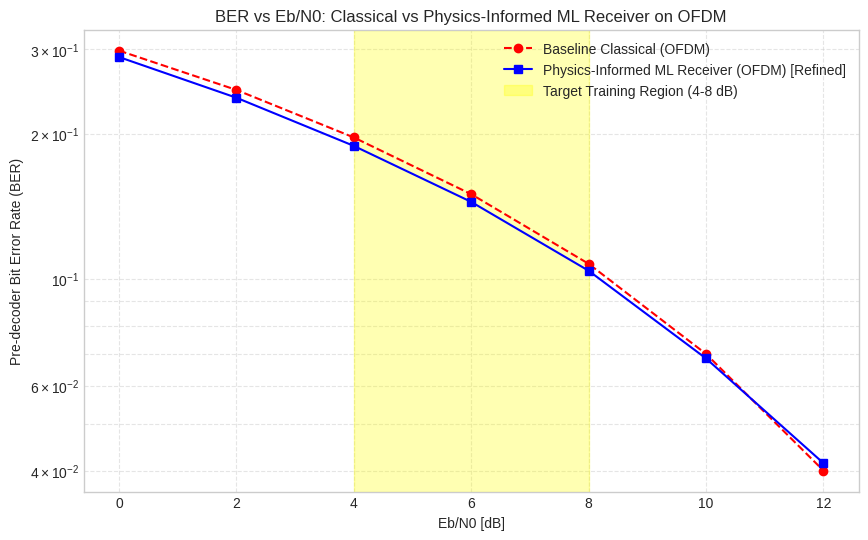

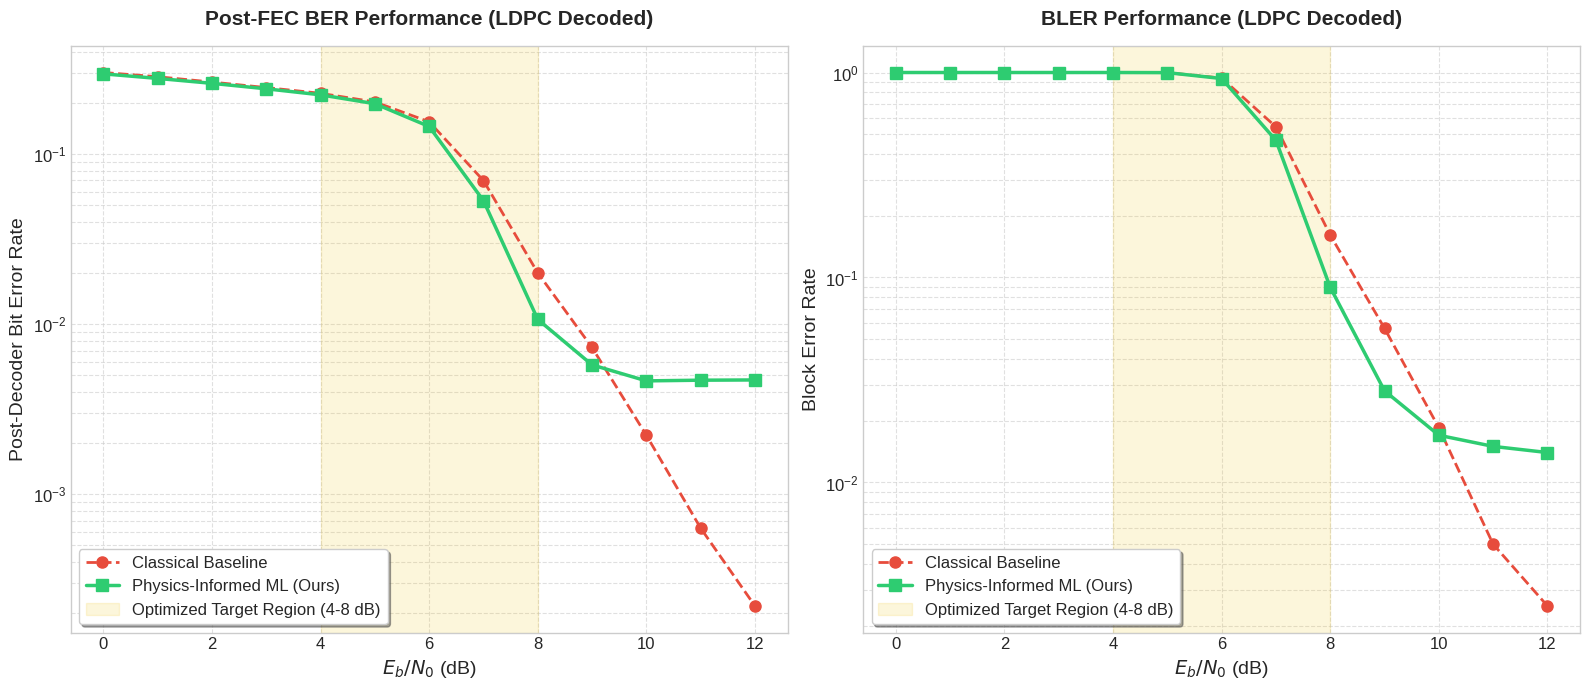

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--', 
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-', 
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--', 
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-', 
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()